## My Question
***What is the probability of rolling at least one 5 or one 7 with a 13-sided die in 5 rolls?***

### My Study
##### 1. The random process is rolling the 13-sided die.
##### 2. One trial will look like rolling the die 5 times. The possible outcomes of this trial include any random combination of 5 separate numbers from a range of 1-13 (and they can repeat), inclusive.
##### 3. The event I'm interested in is whether at least a 5 and a 7 are rolled. The outcomes are either {1, 0} representing either a success or failure (respectively) or rolling a 5 or a 7.

## My Analysis

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
rng = np.random.default_rng()

In [74]:
#since this has a probability of rolling a 5 or 7 in just 5 rolls, I will run a simulation of 1000 trials where each trial contains 5 rolls

number_of_trials = 10_000

# Each row is one trial of flipping 10 coins (1 = Heads, 0 = Tails)
ten_rolls = rng.integers(0, 14, size=(number_of_trials, 5))
fiveOrSevens_per_trial = ((ten_rolls == 5) | (ten_rolls == 7)).sum(axis=1)

simulated = (fiveOrSevens_per_trial >= 1).mean()

print(f"Simulated P(at least one 5 or 7 in 5 rolls): {simulated:.4f}")

Simulated P(at least one 5 or 7 in 5 rolls): 0.5399


In [68]:
#theoretical probability 
#calculate with E' to find the opposite probability first
#not getting 5 or 7 for one roll: 11 other possible numbers divided by the total possible outcomes
notE = (11/13)**5 #raised to the 5th power for 5 rolls
yesE = 1 - notE

print(f"Theoretical P(at least one 5 or 7 in 5 rolls): {yesE:.4f}")

Theoretical P(at least one 5 or 7 in 5 rolls): 0.5662


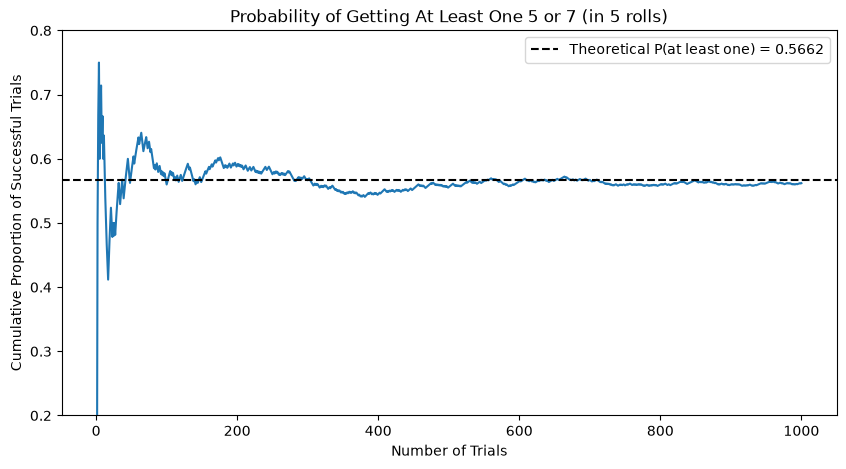

In [81]:
#graph a run through of all 1000 trials of 5 rolls
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

rng = np.random.default_rng()

# Parameters
rolls_per_trial = 5       # Number of rolls in one trial
total_trials = 1000       # Total number of trials

# Theoretical probability of getting AT LEAST ONE 5 or 7 in 5 rolls
# P(at least one) = 1 - P(neither)^5 = 1 - (11/13)^5
theoretical_prob = 1 - (11 / 13) ** rolls_per_trial

# 1. Generate rolls: 1,000 trials, each with 5 rolls
trials_matrix = rng.integers(1, 14, size=(total_trials, rolls_per_trial))

# 2. Check if EACH trial had AT LEAST ONE 5 or 7
trial_success = ((trials_matrix == 5) | (trials_matrix == 7)).any(axis=1).astype(int)

# 3. Create DataFrame and compute cumulative relative frequency
df_run = pd.DataFrame({
    "trial_number": np.arange(1, total_trials + 1),
    "success": trial_success
})

df_run["relative_freq_so_far"] = df_run["success"].cumsum() / df_run["trial_number"]

# 4. Plot using Seaborn
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_run, x="trial_number", y="relative_freq_so_far", color="tab:blue")

# Horizontal reference line for theoretical probability (~0.5376)
plt.axhline(theoretical_prob, color="black", linestyle="--", label=f"Theoretical P(at least one) = {theoretical_prob:.4f}")

plt.title("Probability of Getting At Least One 5 or 7 (in 5 rolls)")
plt.xlabel("Number of Trials")
plt.ylabel("Cumulative Proportion of Successful Trials")
plt.ylim(0.2, 0.8)  # Centered around the ~0.5376 theoretical line
plt.legend()
plt.show()

## My Conclusion
1. The probability of getting a 5 or 7 in five rolls with a 13-sided die is about 55%. The theoretical probability of this is about 56.62%, which was derived mathemateically. On the other hand, the empirical probability was about 54.86%, which was derived using simulations of 5 rolls of a 13-sided die. The average of those values is about 55%, so we can confidently say that this is the probability of rolling a 5 or 7 in 5 trials with a 13-sided die.

2. Present in the previous code cell

3. This is a graph (shown in the previous code cell) that shows the probability of getting at least one 5 or 7 in a trial of 5 rolls. Each trial can only produce a result of 0 or 1, as it is checking whether a 5 or 7 is present or not. The graph shows a cumulative sum average, so that each trial's results are averaged with the ones before it. This is why the 1st few trials are very spread apart, as they have little trials to average with. As the number of trials increases, we can see that the line graph starts to even out and become more evened out along the theoretical line, which is 0.5662. Since the line (towards the end) shows a cumulative average of all the 5-roll trials, we can say that the probability of rolling a 5 or 7 in five rolls is 56.62%